<a href="https://colab.research.google.com/github/bnatsumi/calculo-numerico/blob/main/CN_Atividade_Pr%C3%A1tica_1_NB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática I
**Prof. Raquel J. Lobosco — UNIFESP**

**Integrantes:** _(preencher com os nomes do grupo)_
**Divisão de tarefas:** _(preencher — ex: Parte A: fulano; Parte B: fulana; ...)_

Notebook com as Partes A a E: erro de truncamento e arredondamento,
propagação de erro numa medida de pressão arterial, vazão em Hagen–Poiseuille
(no tubo e no nanocateter), e a diferença entre precisão de ponto flutuante
(`float32` x `float64`) e validade do modelo físico.

## 0. Configuração inicial e funções auxiliares

Todas as funções de truncamento e cálculo de erro usadas no notebook
inteiro ficam centralizadas aqui.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from math import trunc, pi
import imageio.v2 as imageio
from PIL import Image
import io

COR_ORIGINAL = "#6E7F5E"      # green tea leaf (dado original / referência)
COR_ARREDONDADO = "#A8C9A0"   # matcha whisper (arredondado)
COR_TRUNCADO = "#D56B7A"      # berry blush (truncado)
COR_REF = "#6B4E71"            # verde bem escuro, só pra texto e linhas de referência
COR_APOIO = "#FFC75F"         # strawberry milk (destaque)
COR_FUNDO = "#FFF6EE"         # coconut cream
COR_NEUTRO = "#E2DED6"        # silky clay

plt.rcParams.update({
    "figure.facecolor": COR_FUNDO,
    "axes.facecolor": "#FFFCF8",
    "axes.edgecolor": COR_NEUTRO,
    "axes.grid": True,
    "grid.color": COR_NEUTRO,
    "grid.alpha": 0.7,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": COR_REF,
    "text.color": COR_REF,
    "axes.labelcolor": COR_REF,
    "xtick.color": COR_REF,
    "ytick.color": COR_REF,
    "legend.facecolor": "#FFFCF8",
    "legend.edgecolor": COR_NEUTRO,
})


def estiliza_tabela(df, formato=None, largura="auto"):
    """Deixa uma tabela (DataFrame) centralizada e com a cara da paleta,
    em vez do estilo padrão (que fica desalinhado com números de tamanhos
    bem diferentes)."""
    styler = df.style.hide(axis="index")
    if formato:
        styler = styler.format(formato)
    styler = styler.set_table_styles([
        {"selector": "th", "props": [
            ("background-color", COR_ORIGINAL), ("color", "white"),
            ("text-align", "center"), ("padding", "7px 12px"),
            ("font-weight", "600"), ("border", "none"),
        ]},
        {"selector": "td", "props": [
            ("text-align", "center"), ("padding", "6px 12px"),
            ("border-bottom", f"1px solid {COR_NEUTRO}"),
        ]},
        {"selector": "table", "props": [
            ("border-collapse", "collapse"), ("margin", "12px auto"),
            ("background-color", "#FFFCF8"),
        ]},
    ]).set_properties(**{"background-color": "#FFFCF8"})
    return styler


def truncar(x, n):
    """Trunca x para n casas decimais (sem arredondar)."""
    fator = 10 ** n
    return trunc(x * fator) / fator


def arredondar(x, n):
    """Arredonda x para n casas decimais."""
    return round(x, n)


def erro_absoluto(x_ref, x_aprox):
    """Ea = |x - x~|"""
    return abs(x_ref - x_aprox)


def erro_relativo(x_ref, x_aprox):
    """Er = |x - x~| / |x|"""
    return abs(x_ref - x_aprox) / abs(x_ref)


def erro_percentual(x_ref, x_aprox):
    """E% = 100 * Er"""
    return 100 * erro_relativo(x_ref, x_aprox)


print("Funções auxiliares carregadas.")

Funções auxiliares carregadas.


## Parte A — Truncamento e arredondamento

Comparamos, para $n = 0,1,2,3,4$ casas decimais, a aproximação por
truncamento e por arredondamento de três valores de referência.

In [6]:
valores_A = {
    "x1 = 3,14159265": 3.14159265,
    "x2 = 98,76543": 98.76543,
    "x3 = 0,00498765": 0.00498765,
}

linhas_A = []
for nome, x in valores_A.items():
    for n in range(0, 5):
        xt = truncar(x, n)
        xr = arredondar(x, n)
        linhas_A.append({
            "valor": nome, "x_ref": x, "n": n,
            "truncado": xt, "arredondado": xr,
            "Ea_trunc": erro_absoluto(x, xt), "Er_trunc": erro_relativo(x, xt), "E%_trunc": erro_percentual(x, xt),
            "Ea_arred": erro_absoluto(x, xr), "Er_arred": erro_relativo(x, xr), "E%_arred": erro_percentual(x, xr),
        })

tabela_A = pd.DataFrame(linhas_A)
estiliza_tabela(tabela_A, formato={
    "x_ref": "{:.6f}", "n": "{:.0f}",
    "truncado": "{:.6f}", "arredondado": "{:.6f}",
    "Ea_trunc": "{:.2e}", "Er_trunc": "{:.2e}", "E%_trunc": "{:.4f}",
    "Ea_arred": "{:.2e}", "Er_arred": "{:.2e}", "E%_arred": "{:.4f}",
})

valor,x_ref,n,truncado,arredondado,Ea_trunc,Er_trunc,E%_trunc,Ea_arred,Er_arred,E%_arred
"x1 = 3,14159265",3.141593,0,3.000000,3.000000,1.42e-01,4.51e-02,4.5070,1.42e-01,4.51e-02,4.5070
"x1 = 3,14159265",3.141593,1,3.100000,3.100000,4.16e-02,1.32e-02,1.3239,4.16e-02,1.32e-02,1.3239
"x1 = 3,14159265",3.141593,2,3.140000,3.140000,1.59e-03,5.07e-04,0.0507,1.59e-03,5.07e-04,0.0507
"x1 = 3,14159265",3.141593,3,3.141000,3.142000,5.93e-04,1.89e-04,0.0189,4.07e-04,1.30e-04,0.0130
"x1 = 3,14159265",3.141593,4,3.141500,3.141600,9.27e-05,2.95e-05,0.0029,7.35e-06,2.34e-06,0.0002
"x2 = 98,76543",98.765430,0,98.000000,99.000000,7.65e-01,7.75e-03,0.7750,2.35e-01,2.38e-03,0.2375
"x2 = 98,76543",98.765430,1,98.700000,98.800000,6.54e-02,6.62e-04,0.0662,3.46e-02,3.50e-04,0.0350
"x2 = 98,76543",98.765430,2,98.760000,98.770000,5.43e-03,5.50e-05,0.0055,4.57e-03,4.63e-05,0.0046
"x2 = 98,76543",98.765430,3,98.765000,98.765000,4.30e-04,4.35e-06,0.0004,4.30e-04,4.35e-06,0.0004
"x2 = 98,76543",98.765430,4,98.765400,98.765400,3.00e-05,3.04e-07,0.0000,3.00e-05,3.04e-07,0.0000


### Gráfico — erro absoluto ($E_a$) em função de $n$, escala logarítmica

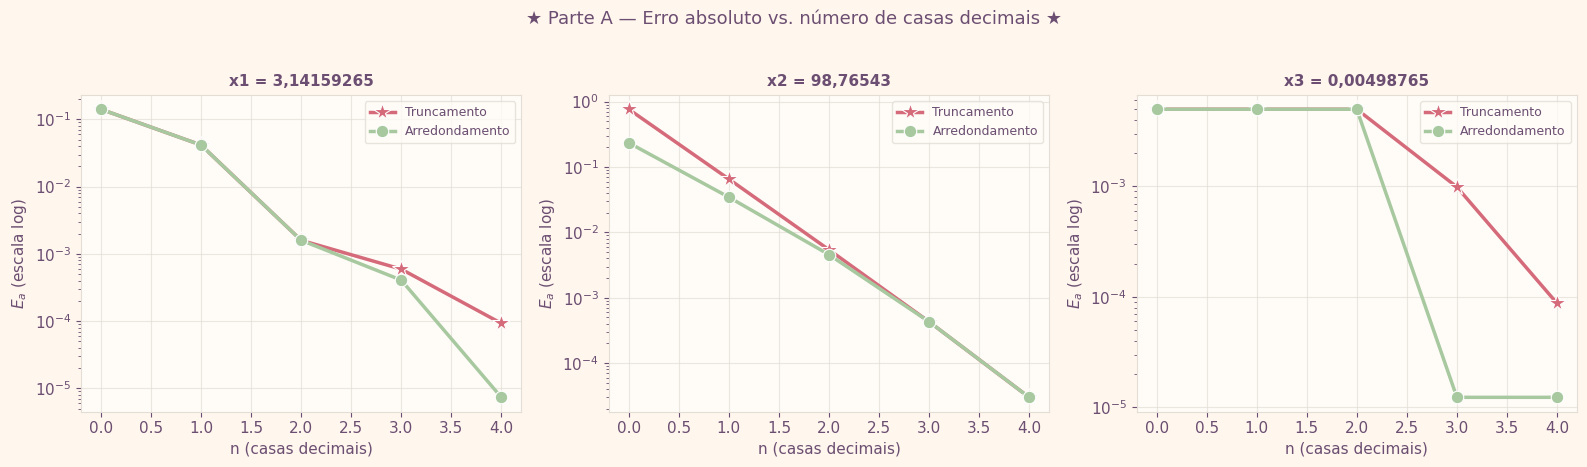

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nome, x) in zip(axs, valores_A.items()):
    sub = tabela_A[tabela_A["valor"] == nome]
    ax.semilogy(sub["n"], sub["Ea_trunc"].replace(0, 1e-18), marker="*", markersize=13,
                linewidth=2.5, color=COR_TRUNCADO, label="Truncamento",
                markeredgecolor="white", markeredgewidth=0.8)
    ax.semilogy(sub["n"], sub["Ea_arred"].replace(0, 1e-18), marker="o", markersize=9,
                linewidth=2.5, color=COR_ARREDONDADO, label="Arredondamento",
                markeredgecolor="white", markeredgewidth=0.8)
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel("n (casas decimais)")
    ax.set_ylabel("$E_a$ (escala log)")
    ax.legend(fontsize=9)
plt.suptitle("★ Parte A — Erro absoluto vs. número de casas decimais ★", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig("parteA_erro_absoluto.png", dpi=150, bbox_inches="tight")
plt.show()

### O que dá pra concluir

Arredondar sempre dá um erro igual ou menor do que truncar. Faz sentido:
ao arredondar a gente pega o valor mais próximo, então o erro máximo é
meio dígito na última casa. Truncar simplesmente corta o resto do número,
sem olhar pra qual lado está mais perto — então o erro pode chegar quase
a um dígito inteiro.

No gráfico dá pra ver isso claramente: a linha do arredondamento fica
sempre igual ou abaixo da linha do truncamento, nos três valores. As
duas curvas só se encostam quando o primeiro algarismo cortado é menor
que 5 — aí tanto faz arredondar ou truncar, dá no mesmo.

## Parte B — Medidas de pressão arterial

Dez medidas de pressão sistólica (mmHg). A referência é a média com
todos os algarismos originais.

O enunciado fala em "quatro séries", mas lista só três (original,
arredondada e truncada). Segui as três que estão descritas — se faltar
uma quarta versão dos dados, vale confirmar com a professora.

In [8]:
medidas = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])

serie_original = medidas
serie_arredondada = np.array([round(v) for v in medidas])
serie_truncada = np.array([trunc(v) for v in medidas])

media_ref = serie_original.mean()

def resumo(serie, nome):
    return {
        "série": nome,
        "média": serie.mean(),
        "mínimo": serie.min(),
        "máximo": serie.max(),
        "amplitude": serie.max() - serie.min(),
        "desvio_padrão_amostral": serie.std(ddof=1),
        "Ea_media": erro_absoluto(media_ref, serie.mean()),
        "Er_media": erro_relativo(media_ref, serie.mean()),
        "E%_media": erro_percentual(media_ref, serie.mean()),
    }

tabela_B = pd.DataFrame([
    resumo(serie_original, "Original"),
    resumo(serie_arredondada, "Arredondada (inteiro)"),
    resumo(serie_truncada, "Truncada (inteiro)"),
])
estiliza_tabela(tabela_B, formato={
    "média": "{:.3f}", "mínimo": "{:.1f}", "máximo": "{:.1f}",
    "amplitude": "{:.1f}", "desvio_padrão_amostral": "{:.3f}",
    "Ea_media": "{:.4f}", "Er_media": "{:.5f}", "E%_media": "{:.3f}",
})

série,média,mínimo,máximo,amplitude,desvio_padrão_amostral,Ea_media,Er_media,E%_media
Original,121.120,119.8,122.4,2.6,0.834,0.0000,0.00000,0.000
Arredondada (inteiro),121.100,120.0,122.0,2.0,0.876,0.0200,0.00017,0.017
Truncada (inteiro),120.700,119.0,122.0,3.0,0.949,0.4200,0.00347,0.347


### Gráfico 1 — as dez medições, três séries

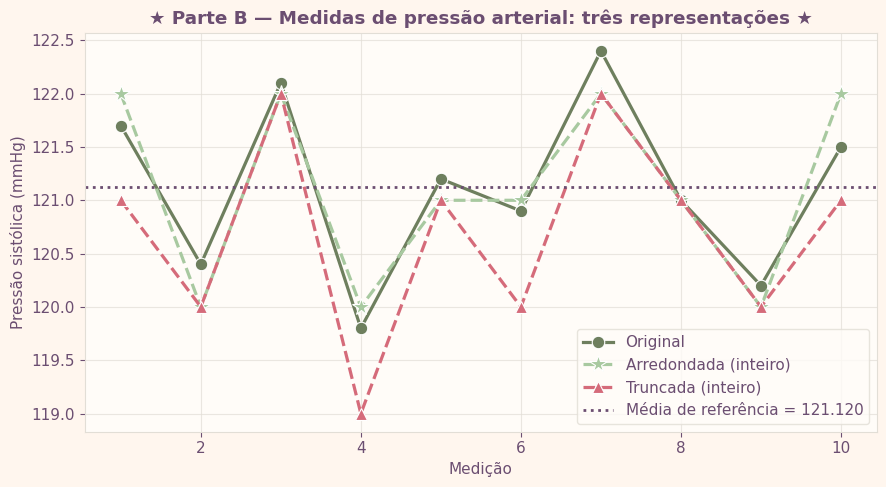

In [9]:
x_idx = np.arange(1, 11)
plt.figure(figsize=(9, 5))
plt.plot(x_idx, serie_original, marker="o", markersize=9, linewidth=2.3, color=COR_ORIGINAL,
         label="Original", markeredgecolor="white", markeredgewidth=0.8)
plt.plot(x_idx, serie_arredondada, marker="*", markersize=13, linewidth=2.3, linestyle="--",
         color=COR_ARREDONDADO, label="Arredondada (inteiro)", markeredgecolor="white", markeredgewidth=0.8)
plt.plot(x_idx, serie_truncada, marker="^", markersize=9, linewidth=2.3, linestyle="--",
         color=COR_TRUNCADO, label="Truncada (inteiro)", markeredgecolor="white", markeredgewidth=0.8)
plt.axhline(media_ref, color=COR_REF, linestyle=":", linewidth=2, label=f"Média de referência = {media_ref:.3f}")
plt.xlabel("Medição")
plt.ylabel("Pressão sistólica (mmHg)")
plt.title("★ Parte B — Medidas de pressão arterial: três representações ★")
plt.legend()
plt.tight_layout()
plt.savefig("parteB_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 2 e 3 — erros absoluto e percentual da média

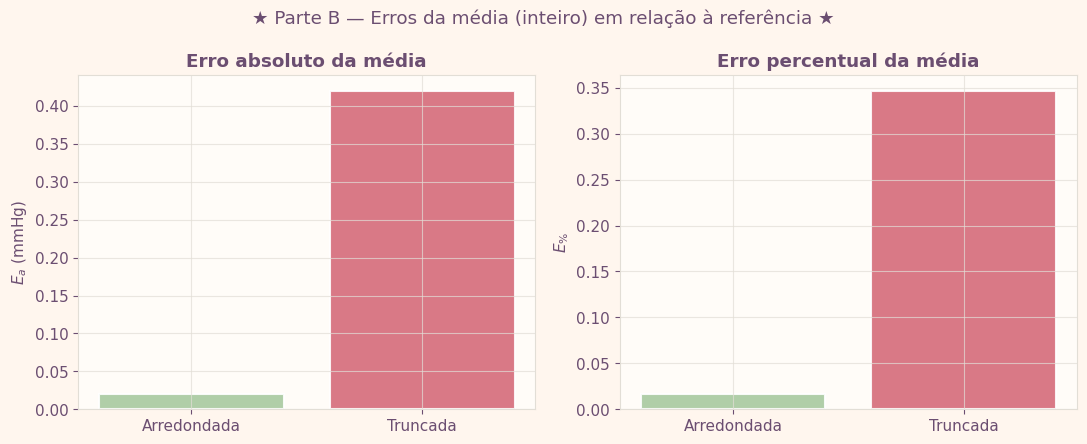

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
series_nomes = ["Arredondada", "Truncada"]
cores_bar = [COR_ARREDONDADO, COR_TRUNCADO]
Ea_vals = [tabela_B.loc[1, "Ea_media"], tabela_B.loc[2, "Ea_media"]]
Ep_vals = [tabela_B.loc[1, "E%_media"], tabela_B.loc[2, "E%_media"]]

axs[0].bar(series_nomes, Ea_vals, color=cores_bar, edgecolor="white", linewidth=1.5, alpha=0.9)
axs[0].set_title("Erro absoluto da média")
axs[0].set_ylabel("$E_a$ (mmHg)")

axs[1].bar(series_nomes, Ep_vals, color=cores_bar, edgecolor="white", linewidth=1.5, alpha=0.9)
axs[1].set_title("Erro percentual da média")
axs[1].set_ylabel("$E_\\%$")

plt.suptitle("★ Parte B — Erros da média (inteiro) em relação à referência ★")
plt.tight_layout()
plt.savefig("parteB_erros_media.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico 4 — histogramas

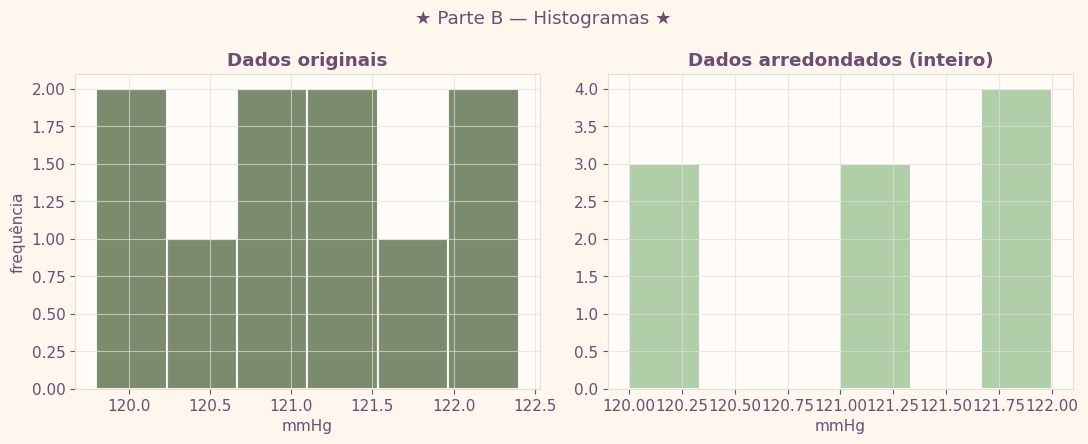

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].hist(serie_original, bins=6, color=COR_ORIGINAL, edgecolor="white", linewidth=1.5, alpha=0.9)
axs[0].set_title("Dados originais")
axs[0].set_xlabel("mmHg")
axs[0].set_ylabel("frequência")

axs[1].hist(serie_arredondada, bins=6, color=COR_ARREDONDADO, edgecolor="white", linewidth=1.5, alpha=0.9)
axs[1].set_title("Dados arredondados (inteiro)")
axs[1].set_xlabel("mmHg")

plt.suptitle("★ Parte B — Histogramas ★")
plt.tight_layout()
plt.savefig("parteB_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

### O que dá pra concluir

Pra essa amostra pequena, arredondar pra inteiro quase não muda a média
(o erro fica bem abaixo de 0,1%) e a distribuição continua com a mesma
cara. O problema é a perda de detalhe: 121,0 e 121,2, por exemplo, viram
o mesmo número depois de arredondar, o que achata um pouco o
desvio-padrão e a amplitude. Então inteiro serve bem se você só quer uma
estimativa rápida da média, mas perde a variação fina que os dados
originais tinham. (Isso é só sobre a representação numérica, sem entrar
em interpretação médica dos valores.)

## Parte C — Vazão em um tubo de pequeno diâmetro

Equação de Hagen–Poiseuille: $Q = \dfrac{\pi r^4 \Delta p}{8 \mu L}$

In [12]:
def vazao_hagen_poiseuille(r, delta_p, mu, L):
    return (pi * r**4 * delta_p) / (8 * mu * L)

# valores de referência (unidades SI: r em metros)
r0_mm, L0, mu0, dp0 = 0.80, 0.20, 3.5e-3, 1200.0
r0 = r0_mm * 1e-3
Q_ref = vazao_hagen_poiseuille(r0, dp0, mu0, L0)
print(f"Q de referência = {Q_ref:.6e} m^3/s")

Q de referência = 2.757421e-07 m^3/s


### C.1 — Precisão das variáveis

In [13]:
r_arred_mm, r_trunc_mm = arredondar(r0_mm, 1), truncar(r0_mm, 1)
mu_arred, mu_trunc = arredondar(mu0, 3), truncar(mu0, 3)
dp_arred = round(dp0 / 100) * 100
dp_trunc = trunc(dp0 / 100) * 100

cenarios_C1 = {
    "1. Todos os valores fornecidos": (r0_mm, dp0, mu0),
    "2a. r arredondado (1 casa, mm)": (r_arred_mm, dp0, mu0),
    "2b. r truncado (1 casa, mm)": (r_trunc_mm, dp0, mu0),
    "3a. mu arredondada (3 casas)": (r0_mm, dp0, mu_arred),
    "3b. mu truncada (3 casas)": (r0_mm, dp0, mu_trunc),
    "4a. dp arredondada (centena)": (r0_mm, dp_arred, mu0),
    "4b. dp truncada (centena)": (r0_mm, dp_trunc, mu0),
    "5a. Todas arredondadas": (r_arred_mm, dp_arred, mu_arred),
    "5b. Todas truncadas": (r_trunc_mm, dp_trunc, mu_trunc),
}

linhas_C1 = []
for nome, (r_mm, dp, mu) in cenarios_C1.items():
    Q = vazao_hagen_poiseuille(r_mm * 1e-3, dp, mu, L0)
    linhas_C1.append({
        "cenário": nome, "r (mm)": r_mm, "Δp (Pa)": dp, "μ (Pa·s)": mu,
        "Q (m³/s)": Q, "Ea": erro_absoluto(Q_ref, Q),
        "Er": erro_relativo(Q_ref, Q), "E% ": erro_percentual(Q_ref, Q),
    })

tabela_C1 = pd.DataFrame(linhas_C1)
estiliza_tabela(tabela_C1, formato={
    "r (mm)": "{:.4f}", "Δp (Pa)": "{:.0f}", "μ (Pa·s)": "{:.4f}",
    "Q (m³/s)": "{:.4e}", "Ea": "{:.4e}", "Er": "{:.5f}", "E% ": "{:.3f}",
})

cenário,r (mm),Δp (Pa),μ (Pa·s),Q (m³/s),Ea,Er,E%
1. Todos os valores fornecidos,0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
"2a. r arredondado (1 casa, mm)",0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
"2b. r truncado (1 casa, mm)",0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
3a. mu arredondada (3 casas),0.8000,1200,0.0040,2.4127e-07,3.4468e-08,0.12500,12.500
3b. mu truncada (3 casas),0.8000,1200,0.0030,3.2170e-07,4.5957e-08,0.16667,16.667
4a. dp arredondada (centena),0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
4b. dp truncada (centena),0.8000,1200,0.0035,2.7574e-07,0.0000e+00,0.00000,0.000
5a. Todas arredondadas,0.8000,1200,0.0040,2.4127e-07,3.4468e-08,0.12500,12.500
5b. Todas truncadas,0.8000,1200,0.0030,3.2170e-07,4.5957e-08,0.16667,16.667


### C.2 — Sensibilidade de Q ao raio

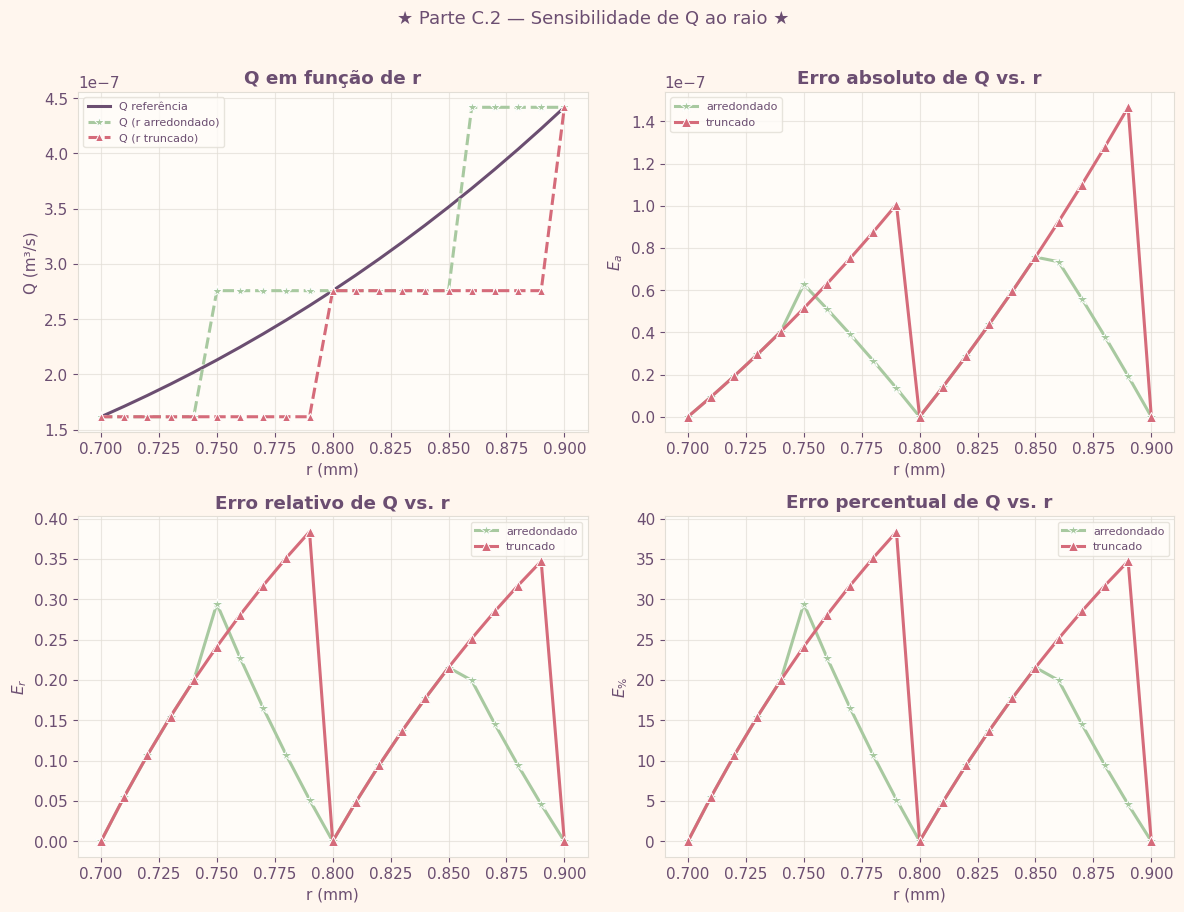

In [14]:
r_vals_mm = np.arange(0.70, 0.901, 0.01)
Q_ref_r = np.array([vazao_hagen_poiseuille(r * 1e-3, dp0, mu0, L0) for r in r_vals_mm])
Q_arred_r = np.array([vazao_hagen_poiseuille(arredondar(r, 1) * 1e-3, dp0, mu0, L0) for r in r_vals_mm])
Q_trunc_r = np.array([vazao_hagen_poiseuille(truncar(r, 1) * 1e-3, dp0, mu0, L0) for r in r_vals_mm])

Ea_arred_r = np.abs(Q_ref_r - Q_arred_r)
Ea_trunc_r = np.abs(Q_ref_r - Q_trunc_r)
Er_arred_r = Ea_arred_r / np.abs(Q_ref_r)
Er_trunc_r = Ea_trunc_r / np.abs(Q_ref_r)
Ep_arred_r = 100 * Er_arred_r
Ep_trunc_r = 100 * Er_trunc_r

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
mk = dict(markeredgecolor="white", markeredgewidth=0.7, linewidth=2.2)

axs[0, 0].plot(r_vals_mm, Q_ref_r, "-", color=COR_REF, linewidth=2.2, label="Q referência")
axs[0, 0].plot(r_vals_mm, Q_arred_r, "--", color=COR_ARREDONDADO, marker="*", markersize=8, label="Q (r arredondado)", **mk)
axs[0, 0].plot(r_vals_mm, Q_trunc_r, "--", color=COR_TRUNCADO, marker="^", markersize=6, label="Q (r truncado)", **mk)
axs[0, 0].set_title("Q em função de r")
axs[0, 0].set_xlabel("r (mm)"); axs[0, 0].set_ylabel("Q (m³/s)"); axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(r_vals_mm, Ea_arred_r, marker="*", markersize=9, color=COR_ARREDONDADO, label="arredondado", **mk)
axs[0, 1].plot(r_vals_mm, Ea_trunc_r, marker="^", markersize=7, color=COR_TRUNCADO, label="truncado", **mk)
axs[0, 1].set_title("Erro absoluto de Q vs. r")
axs[0, 1].set_xlabel("r (mm)"); axs[0, 1].set_ylabel("$E_a$"); axs[0, 1].legend(fontsize=8)

axs[1, 0].plot(r_vals_mm, Er_arred_r, marker="*", markersize=9, color=COR_ARREDONDADO, label="arredondado", **mk)
axs[1, 0].plot(r_vals_mm, Er_trunc_r, marker="^", markersize=7, color=COR_TRUNCADO, label="truncado", **mk)
axs[1, 0].set_title("Erro relativo de Q vs. r")
axs[1, 0].set_xlabel("r (mm)"); axs[1, 0].set_ylabel("$E_r$"); axs[1, 0].legend(fontsize=8)

axs[1, 1].plot(r_vals_mm, Ep_arred_r, marker="*", markersize=9, color=COR_ARREDONDADO, label="arredondado", **mk)
axs[1, 1].plot(r_vals_mm, Ep_trunc_r, marker="^", markersize=7, color=COR_TRUNCADO, label="truncado", **mk)
axs[1, 1].set_title("Erro percentual de Q vs. r")
axs[1, 1].set_xlabel("r (mm)"); axs[1, 1].set_ylabel("$E_\\%$"); axs[1, 1].legend(fontsize=8)

plt.suptitle("★ Parte C.2 — Sensibilidade de Q ao raio ★", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("parteC_sensibilidade_raio.png", dpi=150, bbox_inches="tight")
plt.show()

### O que dá pra concluir

Como Q depende de r elevado à quarta, um erro pequeno no raio vira um
erro bem maior em Q — quase 4 vezes maior, proporcionalmente
($\Delta Q/Q \approx 4 \cdot \Delta r/r$). É por isso que só arredondar
o raio numa casa decimal já aumenta bastante o erro percentual de Q,
mesmo o erro no raio em si sendo pequeno — dá pra ver isso nos gráficos
acima.

## Parte D — Escoamento em um nanocateter

Modelo didático: $r = 50$ nm, $L = 10$ µm, $\mu = 3{,}5\times10^{-3}$ Pa·s,
$\Delta p = 5000$ Pa.

In [ ]:
r_nano_nm, L_nano_um, mu_nano, dp_nano = 50.0, 10.0, 3.5e-3, 5000.0
r_nano = r_nano_nm * 1e-9   # m
L_nano = L_nano_um * 1e-6   # m
Q_nano_ref = vazao_hagen_poiseuille(r_nano, dp_nano, mu_nano, L_nano)
print(f"Q(r=50nm) de referência = {Q_nano_ref:.6e} m^3/s")

### D.1 — Erro geométrico

In [ ]:
delta_r_nm = np.arange(0.1, 5.01, 0.1)  # nm
r_menos_nm = r_nano_nm - delta_r_nm
r_mais_nm = r_nano_nm + delta_r_nm

Q_menos = np.array([vazao_hagen_poiseuille(r * 1e-9, dp_nano, mu_nano, L_nano) for r in r_menos_nm])
Q_mais = np.array([vazao_hagen_poiseuille(r * 1e-9, dp_nano, mu_nano, L_nano) for r in r_mais_nm])
Q_nano_const = np.full_like(delta_r_nm, Q_nano_ref)

Ea_max_D1 = np.maximum(np.abs(Q_mais - Q_nano_ref), np.abs(Q_menos - Q_nano_ref))
Er_max_D1 = Ea_max_D1 / Q_nano_ref
Ep_max_D1 = 100 * Er_max_D1

# aproximação linear: dQ/Q ~= 4 dr/r
aprox_linear = 4 * (delta_r_nm / r_nano_nm)

fig, axs = plt.subplots(2, 2, figsize=(12, 9))

axs[0, 0].plot(delta_r_nm, Q_mais, "-", color=COR_ARREDONDADO, linewidth=2.4, label="Q(r+Δr)")
axs[0, 0].plot(delta_r_nm, Q_nano_const, "-", color=COR_REF, linewidth=2.4, label="Q(r)")
axs[0, 0].plot(delta_r_nm, Q_menos, "-", color=COR_TRUNCADO, linewidth=2.4, label="Q(r−Δr)")
axs[0, 0].set_title("Q(r−), Q(r), Q(r+) vs. Δr")
axs[0, 0].set_xlabel("Δr (nm)"); axs[0, 0].set_ylabel("Q (m³/s)"); axs[0, 0].legend(fontsize=8)

axs[0, 1].plot(delta_r_nm, Ea_max_D1, color=COR_ORIGINAL, linewidth=2.6)
axs[0, 1].fill_between(delta_r_nm, Ea_max_D1, color=COR_ORIGINAL, alpha=0.15)
axs[0, 1].set_title("Erro absoluto máximo de Q")
axs[0, 1].set_xlabel("Δr (nm)"); axs[0, 1].set_ylabel("$E_a$ máx")

axs[1, 0].plot(delta_r_nm, Er_max_D1, color=COR_ORIGINAL, linewidth=2.6, label="erro relativo real")
axs[1, 0].plot(delta_r_nm, aprox_linear, "--", color=COR_TRUNCADO, linewidth=2.2, label="aprox. linear 4·Δr/r")
axs[1, 0].set_title("Erro relativo máximo de Q")
axs[1, 0].set_xlabel("Δr (nm)"); axs[1, 0].set_ylabel("$E_r$ máx"); axs[1, 0].legend(fontsize=8)

axs[1, 1].plot(delta_r_nm, Ep_max_D1, color=COR_ORIGINAL, linewidth=2.6)
axs[1, 1].fill_between(delta_r_nm, Ep_max_D1, color=COR_ORIGINAL, alpha=0.15)
axs[1, 1].set_title("Erro percentual máximo de Q")
axs[1, 1].set_xlabel("Δr (nm)"); axs[1, 1].set_ylabel("$E_\\%$ máx")

plt.suptitle("★ Parte D.1 — Erro geométrico no nanocateter ★", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("parteD1_erro_geometrico.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Erro relativo real em Δr=5nm: {Er_max_D1[-1]:.5f}  |  Aproximação linear: {aprox_linear[-1]:.5f}")

Pra Δr pequeno, a aproximação linear (4·Δr/r) bate quase certinho com o
erro real. Conforme Δr cresce, ela vai ficando um pouco abaixo do valor
real, porque essa fórmula ignora os termos de ordem maior que vêm do r⁴
— funciona bem como estimativa rápida, mas não é exata pra variações
grandes.

### D.2 — Precisão computacional (float32 vs float64)

In [ ]:
r32, r64 = np.float32(r_nano), np.float64(r_nano)
dp32, dp64 = np.float32(dp_nano), np.float64(dp_nano)
mu32, mu64 = np.float32(mu_nano), np.float64(mu_nano)
L32, L64 = np.float32(L_nano), np.float64(L_nano)

r4_32 = r32**4
r4_64 = r64**4
Q_32 = vazao_hagen_poiseuille(r32, dp32, mu32, L32)
Q_64 = vazao_hagen_poiseuille(r64, dp64, mu64, L64)

diff_abs = abs(float(Q_64) - float(Q_32))
diff_rel = diff_abs / abs(float(Q_64))

tabela_D2 = pd.DataFrame([{
    "r^4 (float32)": r4_32, "r^4 (float64)": r4_64,
    "Q (float32)": Q_32, "Q (float64)": Q_64,
    "|ΔQ| abs": diff_abs, "|ΔQ| rel": diff_rel,
    "eps float32": np.finfo(np.float32).eps, "eps float64": np.finfo(np.float64).eps,
}])
estiliza_tabela(tabela_D2, formato="{:.4e}")

### Cancelamento numérico: δ1 (expressão direta) vs. δ2 (expandida)

In [ ]:
razoes = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8])

def delta1(dtype, razao):
    r = dtype(r_nano); dr = dtype(r_nano * razao)
    Q_r = vazao_hagen_poiseuille(r, dtype(dp_nano), dtype(mu_nano), dtype(L_nano))
    Q_rdr = vazao_hagen_poiseuille(r + dr, dtype(dp_nano), dtype(mu_nano), dtype(L_nano))
    return (Q_rdr - Q_r) / Q_r

def delta2(dtype, razao):
    return (dtype(1) + dtype(razao)) ** 4 - dtype(1)

linhas_D2b = []
for razao in razoes:
    d1_32, d1_64 = delta1(np.float32, razao), delta1(np.float64, razao)
    d2_32, d2_64 = delta2(np.float32, razao), delta2(np.float64, razao)
    linhas_D2b.append({
        "Δr/r": razao,
        "δ1 (float32)": float(d1_32), "δ2 (float32)": float(d2_32),
        "diff float32": abs(float(d1_32) - float(d2_32)),
        "δ1 (float64)": float(d1_64), "δ2 (float64)": float(d2_64),
        "diff float64": abs(float(d1_64) - float(d2_64)),
    })
tabela_D2b = pd.DataFrame(linhas_D2b)
estiliza_tabela(tabela_D2b, formato={
    "Δr/r": "{:.0e}", "δ1 (float32)": "{:.6e}", "δ2 (float32)": "{:.6e}",
    "diff float32": "{:.2e}", "δ1 (float64)": "{:.6e}", "δ2 (float64)": "{:.6e}",
    "diff float64": "{:.2e}",
})

Quando Δr/r fica bem pequeno, δ1 está subtraindo dois números quase
iguais — Q(r+Δr) e Q(r) — e isso faz perder precisão (o famoso
cancelamento catastrófico). Isso aparece primeiro no float32, que tem
menos casas decimais disponíveis (eps maior); no float64 só acontece
pra razões ainda menores. A δ2, calculada de outro jeito, sofre um
cancelamento parecido no final da conta, mas costuma preservar mais
dígitos porque os números envolvidos ficam menores no meio do caminho.

### D.3 — Fenômeno físico

Quando o canal fica tão pequeno assim — nanômetros em vez de milímetros
— a razão entre superfície e volume aumenta bastante. Pensa assim: o
volume cresce com r², mas o contato com a parede cresce com r. Então
quanto menor o raio, maior a fatia do fluido que fica perto da parede —
e é bem ali que a velocidade do fluido é freada (a condição de
não-deslizamento). Por isso, na escala do nanocateter, os efeitos de
parede e a viscosidade pesam muito mais do que num tubo comum.

Tem um ponto importante aqui: dá pra calcular Q com 10 casas decimais
certinhas em `float64` e, mesmo assim, esse número não representar bem a
física real — porque nessa escala, a própria ideia de escoamento laminar
contínuo pode deixar de fazer sentido. Precisão numérica e validade do
modelo físico são coisas diferentes.

## Parte E — Síntese visual (PNG único)

Painel único ≥ 1600×1000 px com os principais resultados do notebook.

In [4]:
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(18, 11.5), dpi=110)
fig.patch.set_facecolor(COR_FUNDO)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.65, wspace=0.38,
                        left=0.05, right=0.97, top=0.90, bottom=0.05)

fig.suptitle("★ Cálculo Numérico — Painel de Síntese (Atividade Prática I) ★",
             fontsize=19, fontweight="bold", color=COR_REF, y=0.965)

# --- Cartões de valores principais ---
ax_cards = fig.add_subplot(gs[0, 0])
ax_cards.axis("off")
ax_cards.set_xlim(0, 1); ax_cards.set_ylim(0, 1)
ax_cards.set_title("Valores-chave", fontsize=13, fontweight="bold", pad=12)

cartoes = [
    ("Tubo (Parte C)", f"r = {r0_mm} mm   Δp = {dp0} Pa\nQ ref. = {Q_ref:.3e} m³/s", COR_ORIGINAL),
    ("Nanocateter (Parte D)", f"r = {r_nano_nm} nm   Δp = {dp_nano} Pa\nQ ref. = {Q_nano_ref:.3e} m³/s", COR_TRUNCADO),
    ("Pressão arterial (Parte B)", f"Média ref. = {media_ref:.2f} mmHg\nDesvio padrão = {serie_original.std(ddof=1):.2f}", COR_ARREDONDADO),
]
alturas = [0.90, 0.58, 0.26]  # topo de cada cartão
altura_cartao = 0.26
for (titulo, texto, cor), y_topo in zip(cartoes, alturas):
    box = FancyBboxPatch((0.03, y_topo - altura_cartao), 0.94, altura_cartao,
                          boxstyle="round,pad=0,rounding_size=0.035",
                          transform=ax_cards.transAxes,
                          facecolor=cor, alpha=0.16, edgecolor=cor, linewidth=1.6)
    ax_cards.add_patch(box)
    ax_cards.text(0.08, y_topo - 0.07, titulo, transform=ax_cards.transAxes,
                  fontsize=11, fontweight="bold", color=cor, va="top")
    ax_cards.text(0.08, y_topo - 0.15, texto, transform=ax_cards.transAxes,
                  fontsize=9, color=COR_REF, va="top", linespacing=1.6)

# --- Truncamento x arredondamento (Parte A, resumo) ---
ax1 = fig.add_subplot(gs[0, 1])
sub = tabela_A[tabela_A["valor"] == "x1 = 3,14159265"]
ax1.semilogy(sub["n"], sub["Ea_trunc"].replace(0, 1e-18), marker="*", markersize=9,
             color=COR_TRUNCADO, label="Truncamento")
ax1.semilogy(sub["n"], sub["Ea_arred"].replace(0, 1e-18), marker="o", markersize=6,
             color=COR_ARREDONDADO, label="Arredondamento")
ax1.set_title("Truncamento x arredondamento", fontsize=10.5, pad=10)
ax1.set_xlabel("n"); ax1.set_ylabel("$E_a$")
ax1.legend(fontsize=7.5, loc="upper right")

# --- Três tipos de erro (Parte B, barras) ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(["$E_a$", "$E_r$\n(×1000)", "$E_\\%$"],
        [tabela_B.loc[1, "Ea_media"], tabela_B.loc[1, "Er_media"] * 1000, tabela_B.loc[1, "E%_media"]],
        color=[COR_ORIGINAL, COR_APOIO, COR_ARREDONDADO], edgecolor="white", linewidth=1.2)
ax2.set_title("Três tipos de erro\n(média arredondada, Parte B)", fontsize=10.5, pad=10)

# --- Sensibilidade de Q ao raio (Parte C) ---
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(r_vals_mm, Q_ref_r, "-", color=COR_REF, linewidth=2, label="Q referência")
ax3.plot(r_vals_mm, Q_arred_r, "--", color=COR_ARREDONDADO, linewidth=1.8, label="Q (r arredondado)")
ax3.plot(r_vals_mm, Q_trunc_r, "--", color=COR_TRUNCADO, linewidth=1.8, label="Q (r truncado)")
ax3.set_title("Sensibilidade de Q ao raio (Parte C.2)", fontsize=11.5, pad=10)
ax3.set_xlabel("r (mm)"); ax3.set_ylabel("Q (m³/s)")
ax3.legend(fontsize=8, loc="lower right")

# --- float32 x float64 (Parte D.2) ---
ax4 = fig.add_subplot(gs[1, 2])
ax4.bar(["float32", "float64"], [np.finfo(np.float32).eps, np.finfo(np.float64).eps],
        color=[COR_TRUNCADO, COR_ORIGINAL], edgecolor="white", linewidth=1.5)
ax4.set_yscale("log")
ax4.set_title("eps: float32 x float64", fontsize=10.5, pad=10)
ax4.set_ylabel("eps (log)")

# --- Erro relativo máximo no nanocateter (Parte D.1) ---
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(delta_r_nm, Er_max_D1, color=COR_ORIGINAL, linewidth=2.2, label="erro relativo real")
ax5.plot(delta_r_nm, aprox_linear, "--", color=COR_TRUNCADO, linewidth=1.8, label="aprox. linear 4Δr/r")
ax5.set_title("Erro geométrico no nanocateter (Parte D.1)", fontsize=11.5, pad=10)
ax5.set_xlabel("Δr (nm)"); ax5.set_ylabel("$E_r$ máx")
ax5.legend(fontsize=8, loc="upper left")

# --- Conclusão ---
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
ax6.set_xlim(0, 1); ax6.set_ylim(0, 1)
box_concl = FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                            boxstyle="round,pad=0,rounding_size=0.04",
                            transform=ax6.transAxes,
                            facecolor=COR_ARREDONDADO, alpha=0.14,
                            edgecolor=COR_ARREDONDADO, linewidth=1.6)
ax6.add_patch(box_concl)
ax6.text(0.10, 0.86, "Conclusão", fontsize=13, fontweight="bold", color=COR_REF,
         transform=ax6.transAxes, va="top")
ax6.text(0.10, 0.70,
         "No nanocateter, o expoente 4 de Q em r amplia bastante\n"
         "qualquer erro no raio, e a escala nanométrica ainda\n"
         "aumenta os efeitos de parede. Ter muitas casas\n"
         "decimais não garante que o modelo esteja certo.",
         fontsize=9.5, color=COR_REF, transform=ax6.transAxes, va="top", linespacing=1.7)

plt.savefig("parteE_painel_sintese.png", dpi=110, bbox_inches="tight", facecolor=COR_FUNDO)
plt.show()

from PIL import Image as PILImage
img_check = PILImage.open("parteE_painel_sintese.png")
print(f"Dimensões do PNG final: {img_check.size} px")

NameError: name 'plt' is not defined

## GIF demonstrativo

41 quadros com o raio do nanocateter variando de 45 a 55 nm. Cada quadro
mostra a seção transversal do canal, o raio e a vazão atuais, o erro
percentual em relação a $r=50$ nm, e a curva $Q \times r$ sendo
construída progressivamente.

In [2]:
r_gif = np.linspace(45, 55, 41)  # nm, 41 quadros
Q_gif = np.array([vazao_hagen_poiseuille(r * 1e-9, dp_nano, mu_nano, L_nano) for r in r_gif])
Ep_gif = 100 * np.abs(Q_gif - Q_nano_ref) / Q_nano_ref

import matplotlib.patheffects as pe

frames = []
for i in range(len(r_gif)):
    fig, axs = plt.subplots(1, 2, figsize=(9.5, 4.4), dpi=110)
    fig.patch.set_facecolor("#FFF7FB")

    # seção transversal (círculo) — bem fofinho, com "brilho"
    ax_c = axs[0]
    glow = plt.Circle((0, 0), r_gif[i] * 1.15, color=COR_ARREDONDADO, alpha=0.18)
    ax_c.add_patch(glow)
    circ = plt.Circle((0, 0), r_gif[i], color=COR_TRUNCADO, alpha=0.8, ec="white", lw=2)
    ax_c.add_patch(circ)
    ref_circ = plt.Circle((0, 0), 50, fill=False, linestyle="--", color=COR_REF, linewidth=1.3)
    ax_c.add_patch(ref_circ)
    ax_c.plot(0, 0, marker="*", markersize=14, color=COR_APOIO, markeredgecolor="white", markeredgewidth=0.6)
    ax_c.set_xlim(-58, 58); ax_c.set_ylim(-58, 58)
    ax_c.set_aspect("equal")
    ax_c.set_title("♡ Seção transversal do canal ♡", fontsize=10.5)
    ax_c.text(0, -53, f"r = {r_gif[i]:.2f} nm   Q = {Q_gif[i]:.3e} m³/s\nE% vs r=50nm: {Ep_gif[i]:.2f}%",
               ha="center", fontsize=8.5, color=COR_REF,
               bbox=dict(boxstyle="round,pad=0.35", facecolor="#FFF0F7", edgecolor=COR_REF, linewidth=0.8))
    ax_c.set_xlabel("nm"); ax_c.set_ylabel("nm")

    # curva Q x r sendo construída
    ax_q = axs[1]
    ax_q.plot(r_gif[:i+1], Q_gif[:i+1], "-", color=COR_ARREDONDADO, linewidth=2.2)
    ax_q.plot(r_gif[i], Q_gif[i], marker="*", markersize=15, color=COR_APOIO,
              markeredgecolor="white", markeredgewidth=0.8,
              path_effects=[pe.withStroke(linewidth=3, foreground=COR_REF, alpha=0.15)])
    ax_q.axvline(50, color=COR_REF, linestyle=":", linewidth=1.3)
    ax_q.set_xlim(44, 56)
    ax_q.set_ylim(Q_gif.min() * 0.95, Q_gif.max() * 1.05)
    ax_q.set_title("♡ Curva Q × r (construção progressiva) ♡", fontsize=10.5)
    ax_q.set_xlabel("r (nm)"); ax_q.set_ylabel("Q (m³/s)")

    plt.suptitle(f"★ Nanocateter — quadro {i+1}/{len(r_gif)} ★", fontsize=12, color=COR_REF, fontweight="bold")
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=110, facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave("nanocateter_demo.gif", frames, duration=0.12, loop=0)
print(f"GIF gerado com {len(frames)} quadros: nanocateter_demo.gif")

NameError: name 'np' is not defined

### Exibindo o GIF aqui no notebook

In [ ]:
from IPython.display import Image as IPyImage, display
display(IPyImage(filename="nanocateter_demo.gif"))

## Conclusão

O truncamento e o arredondamento causam erros pequenos por si só, mas
como eles se propagam depende muito da equação. Na pressão arterial, a
propagação é quase linear, então arredondar pra inteiro quase não muda
nada. Já em Hagen–Poiseuille, como Q depende de r⁴, qualquer erro no
raio vira um erro bem maior em Q — e isso pesa ainda mais na escala do
nanocateter, onde a física de parede também entra em jogo.

A comparação entre `float32` e `float64` mostra outro tipo de limite:
mesmo sem nenhum erro de arredondamento "manual", o computador já tem
sua própria precisão limitada, e comparar δ1 com δ2 mostra como isso
pode dar problema quando os números ficam muito próximos uns dos
outros. São dois problemas diferentes — erro de representação decimal
e erro de ponto flutuante — mas os dois mostram a mesma lição: um
resultado com muitos dígitos não significa, sozinho, que ele está
certo.